# Telco Customer Churn — Exploratory Data Analysis (Outline Only)

**Author:** Allison Schiltz

> Dataset reference: *Telco Customer Churn* (Kaggle).
https://www.kaggle.com/datasets/blastchar/telco-customer-churn/code


**Inputs expected**
- Cleaned dataset from `data/processed/`
- Column-role manifest from data-wrangling handoff (ID, target, numeric, categorical, booleans)

**Primary goals**
- Understand target distribution and key drivers
- Identify relationships, interactions, and potential leakage
- Inform feature engineering and modeling choices


## 0. Environment & Imports (no code provided here)

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical analysis
from scipy import stats
import math

# Data profiling (optional - for quick reports)
from ydata_profiling import ProfileReport

# Warning management
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Display options for better output
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)
plt.style.use('default')
%matplotlib inline

print("Environment | pandas", pd.__version__, "| numpy", np.__version__)

Environment | pandas 2.3.0 | numpy 2.1.3


## 1. Load Clean Data & Manifests
- Load processed dataset from `data/processed/`
- Load column-role manifest
- Basic integrity checks (shape, dtypes, head/tail)


In [2]:
# Load cleaned dataset
telco_clean = pd.read_csv('../data/processed/telco_wrangling_cleaned.csv')

# Load column-role manifest  
column_roles = pd.read_csv('../references/telco_column_role_manifest_template.csv')

# Basic integrity checks
print("Shape:", telco_clean.shape)
print("Info:")
telco_clean.info()
print("\nHead:")
print(telco_clean.head())
print("\nColumn roles:")
print(column_roles)

Shape: (7032, 26)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   customerID                       7032 non-null   object 
 1   gender                           7032 non-null   object 
 2   SeniorCitizen                    7032 non-null   object 
 3   Partner                          7032 non-null   object 
 4   Dependents                       7032 non-null   object 
 5   tenure                           7032 non-null   int64  
 6   PhoneService                     7032 non-null   object 
 7   MultipleLines                    7032 non-null   object 
 8   InternetService                  7032 non-null   object 
 9   OnlineSecurity                   7032 non-null   object 
 10  OnlineBackup                     7032 non-null   object 
 11  DeviceProtection                 7032 non-null   object 
 

In [3]:
# Convert categorical, boolean, and target columns to proper dtypes
categorical_columns = column_roles[column_roles['role'].isin(['categorical', 'boolean', 'target'])]['column_name']

for col in categorical_columns:
    telco_clean[col] = telco_clean[col].astype('category')

# Convert engineered boolean to categorical for consistency

telco_clean['short_tenure_month_to_month_eng'] = telco_clean['short_tenure_month_to_month_eng'].map({True: 'Yes', False: 'No'}).astype('category')

print("\nUpdated data types:")
# Sort by data type name (convert to string first to avoid comparison issues)
print(telco_clean.dtypes.astype(str).sort_values())



Updated data types:
TechSupport                        category
monthly_charges_bin_eng            category
tenure_group_eng                   category
Churn                              category
PaymentMethod                      category
PaperlessBilling                   category
Contract                           category
StreamingMovies                    category
StreamingTV                        category
is_month_to_month_eng              category
DeviceProtection                   category
short_tenure_month_to_month_eng    category
OnlineSecurity                     category
InternetService                    category
MultipleLines                      category
PhoneService                       category
Dependents                         category
Partner                            category
SeniorCitizen                      category
gender                             category
OnlineBackup                       category
MonthlyCharges                      float64
TotalCharge

## 2. Target Variable Audit (`Churn`)
- Class balance (counts, percentages)


Churn counts: Churn
No     5163
Yes    1869
Name: count, dtype: int64 

Churn proportion: Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64 

Churn missing values: 0


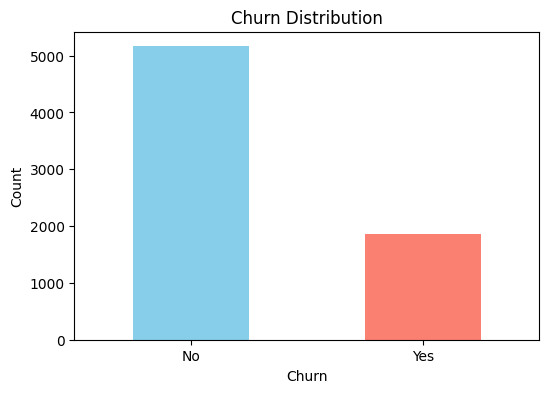

In [4]:
churn_counts = telco_clean['Churn'].value_counts()
print("Churn counts:", churn_counts, "\n")

churn_proportion = telco_clean['Churn'].value_counts(normalize=True)
print("Churn proportion:", churn_proportion, "\n")

print("Churn missing values:", telco_clean['Churn'].isnull().sum())

plt.figure(figsize=(6, 4))
churn_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


## 3. Univariate Exploration
### 3.1 Numeric
- Distribution plots, summary stats, skewness/kurtosis

In [5]:
# Identify numeric columns
count_roles = column_roles['role'].value_counts()
print(count_roles, '\n')
numeric_cols = column_roles[column_roles['role'] == 'numeric']['column_name']
print(numeric_cols)

role
categorical    18
numeric         4
boolean         2
id              1
target          1
Name: count, dtype: int64 

2                 tenure
3         MonthlyCharges
4           TotalCharges
22    total_services_eng
Name: column_name, dtype: object


In [6]:
# Identify all non-numeric columns by dtype (excluding target)
all_non_numeric = telco_clean.select_dtypes(include=['category']).columns
all_non_numeric = all_non_numeric[all_non_numeric != 'Churn']  # Exclude target variable
print(f'All non-numeric predictor columns ({len(all_non_numeric)} total):')
print(all_non_numeric.tolist())
for col_name in all_non_numeric:
    print(f"value counts:")
    print(telco_clean[col_name].value_counts(), '\n')
    print(f"proportion:")
    print(telco_clean[col_name].value_counts(normalize=True), '\n')

    # Flag rare categories (< 5% of data)
    rare_threshold = len(telco_clean) * 0.05
    rare_cats = telco_clean[col_name].value_counts() < rare_threshold
    print('Rare categories (< 5% of data):')
    if rare_cats.any():
        print(rare_cats[rare_cats].index.tolist())
    else:
        print("None")


All non-numeric predictor columns (20 total):
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group_eng', 'monthly_charges_bin_eng', 'is_month_to_month_eng', 'short_tenure_month_to_month_eng']
value counts:
gender
Male      3549
Female    3483
Name: count, dtype: int64 

proportion:
gender
Male      0.504693
Female    0.495307
Name: proportion, dtype: float64 

Rare categories (< 5% of data):
None
value counts:
SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64 

proportion:
SeniorCitizen
No     0.8376
Yes    0.1624
Name: proportion, dtype: float64 

Rare categories (< 5% of data):
None
value counts:
Partner
No     3639
Yes    3393
Name: count, dtype: int64 

proportion:
Partner
No     0.517491
Yes    0.482509
Name: proportion, dtype: float64 

Rare categories

In [7]:
# Generate basic ydata profilingreport
profile = ProfileReport(telco_clean, title="Telco EDA Profile", minimal=True)
profile.to_notebook_iframe() 

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:00<00:00, 166746.03it/s]



Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 4. Bivariate Analysis vs Target
### 4.1 Numeric vs `Churn`
- Compare distributions by class
- Simple effect sizes


Numeric columns: ['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services_eng']


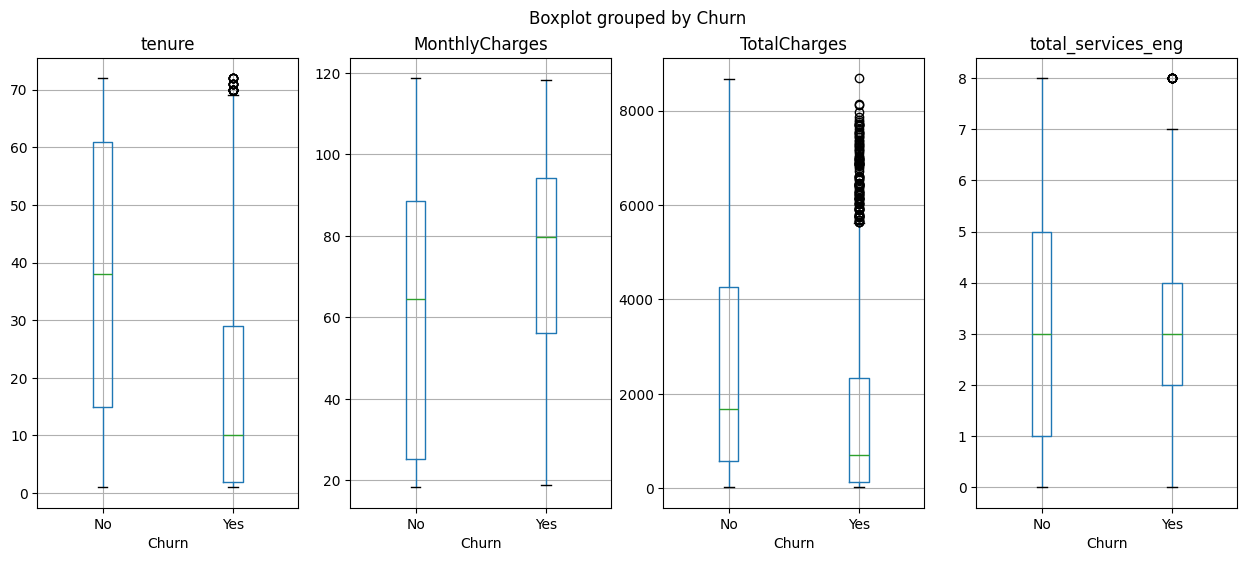

In [8]:
print('Numeric columns:', numeric_cols.tolist())

# Compare distributions by churn status
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(15, 6))
for i, col in enumerate(numeric_cols):
    # Box plot by churn
    telco_clean.boxplot(column=col, by='Churn', ax=axes[i])

In [9]:
# Group statistics
for col in numeric_cols:
    print(f"\n{col}:")
    stats = telco_clean.groupby('Churn')[col].agg(['mean', 'median', 'std'])
    print(stats)


tenure:
            mean  median        std
Churn                              
No     37.650010    38.0  24.076940
Yes    17.979133    10.0  19.531123

MonthlyCharges:
            mean  median        std
Churn                              
No     61.307408   64.45  31.094557
Yes    74.441332   79.65  24.666053

TotalCharges:
              mean   median          std
Churn                                   
No     2555.344141  1683.60  2329.456984
Yes    1531.796094   703.55  1890.822994

total_services_eng:
           mean  median       std
Churn                            
No     3.447027     3.0  2.156609
Yes    3.132156     3.0  1.754828


In [23]:
# Cohen's d for effect size
# 0.2 = small effect
# 0.5 = medium effect  
# 0.8 = large effect

import pingouin as pg

# Store Cohen's d results for summary table
cohens_d_results = []

for col in numeric_cols:
    churn_yes = telco_clean[telco_clean['Churn'] == 'Yes'][col]
    churn_no = telco_clean[telco_clean['Churn'] == 'No'][col]
    
    # Calculate Cohen's d using Pingouin
    d = pg.compute_effsize(churn_yes, churn_no, eftype='cohen')
    
    # Interpret effect size
    abs_d = abs(d)
    if abs_d < 0.2:
        effect = "negligible"
    elif abs_d < 0.5:
        effect = "small"
    elif abs_d < 0.8:
        effect = "medium"
    else:
        effect = "large"
    
    # Store results for summary table
    cohens_d_results.append({
        'Variable': col,
        'Type': 'Numeric',
        'Effect_Size': abs_d,  # Use absolute value for ranking
        'Raw_Effect_Size': d,  # Keep original for reference
        'Effect_Magnitude': effect
    })
    
    print(f"{col}: Cohen's d = {d:.3f} ({effect})")

tenure: Cohen's d = -0.857 (large)
MonthlyCharges: Cohen's d = 0.445 (small)
TotalCharges: Cohen's d = -0.461 (small)
total_services_eng: Cohen's d = -0.153 (negligible)



### 4.2 Categorical vs `Churn`
- Grouped churn rates
- Association measures (Cramér's V / Theil’s U as applicable)

> Record notable relationships and candidate features.


In [11]:
# Calculate overall churn rate
overall_churn_rate = telco_clean['Churn'].value_counts(normalize=True)['Yes']

# Calculate churn rates by category for each categorical variable
for col in all_non_numeric:
    print(f"\n{col} - Churn Rates:")
    churn_rates = telco_clean.groupby(col)['Churn'].value_counts(normalize=True).unstack()
    print(churn_rates)
    
    # Highlight categories with above-average churn rates
    if 'Yes' in churn_rates.columns:
        high_churn = churn_rates['Yes'] > overall_churn_rate
        if high_churn.any():
            print(f"  Above-average churn categories (>{overall_churn_rate:.1%}): {high_churn[high_churn].index.tolist()[0]}")
    print()


gender - Churn Rates:
Churn         No       Yes
gender                    
Female  0.730405  0.269595
Male    0.737954  0.262046
  Above-average churn categories (>26.6%): Female


SeniorCitizen - Churn Rates:
Churn                No       Yes
SeniorCitizen                    
No             0.763497  0.236503
Yes            0.583187  0.416813
  Above-average churn categories (>26.6%): Yes


Partner - Churn Rates:
Churn          No       Yes
Partner                    
No       0.670239  0.329761
Yes      0.802829  0.197171
  Above-average churn categories (>26.6%): No


Dependents - Churn Rates:
Churn             No       Yes
Dependents                    
No          0.687209  0.312791
Yes         0.844688  0.155312
  Above-average churn categories (>26.6%): No


PhoneService - Churn Rates:
Churn               No       Yes
PhoneService                    
No            0.750000  0.250000
Yes           0.732525  0.267475
  Above-average churn categories (>26.6%): Yes


MultipleLines

In [24]:
# Association measures (effect sizes) for categorical vs churn
print(f"Overall churn rate: {overall_churn_rate:.1%}\n")
print("Association Measures (Categorical vs Churn):")
print("=" * 50)

# Store Cramér's V results for summary table
cramers_v_results = []

for col in all_non_numeric:
    print(f"\n{col}:")
    
    # Use Pingouin's chi2_independence with column names
    chi2_results = pg.chi2_independence(data=telco_clean, x=col, y='Churn')
    cramers_v = chi2_results[2]['cramer'].iloc[0]  # Extract Cramér's V from the third element (stats DataFrame)
    
    print(f"  Cramér's V: {cramers_v:.3f}")
    
    # Interpret Cramér's V strength
    if cramers_v < 0.1:
        strength = "negligible"
    elif cramers_v < 0.3:
        strength = "weak"
    elif cramers_v < 0.5:
        strength = "moderate"
    else:
        strength = "strong"
    
    # Store results for summary table
    cramers_v_results.append({
        'Variable': col,
        'Type': 'Categorical',
        'Effect_Size': cramers_v,
        'Raw_Effect_Size': cramers_v,  # Same as Effect_Size for Cramér's V
        'Effect_Magnitude': strength
    })
    
    print(f"  Association strength: {strength}")

Overall churn rate: 26.6%

Association Measures (Categorical vs Churn):

gender:
  Cramér's V: 0.008
  Association strength: negligible

SeniorCitizen:
  Cramér's V: 0.150
  Association strength: weak

Partner:
  Cramér's V: 0.150
  Association strength: weak

Dependents:
  Cramér's V: 0.163
  Association strength: weak

PhoneService:
  Cramér's V: 0.011
  Association strength: negligible

MultipleLines:
  Cramér's V: 0.040
  Association strength: negligible

InternetService:
  Cramér's V: 0.322
  Association strength: moderate

OnlineSecurity:
  Cramér's V: 0.347
  Association strength: moderate

OnlineBackup:
  Cramér's V: 0.292
  Association strength: weak

DeviceProtection:
  Cramér's V: 0.281
  Association strength: weak

TechSupport:
  Cramér's V: 0.343
  Association strength: moderate

StreamingTV:
  Cramér's V: 0.230
  Association strength: weak

StreamingMovies:
  Cramér's V: 0.231
  Association strength: weak

Contract:
  Cramér's V: 0.410
  Association strength: moderate

Pa

In [38]:
# Bivariate summary with separate tables for numeric and categorical
print("\n" + "="*60)
print("BIVARIATE SUMMARY: CHURN PREDICTORS BY TYPE")
print("="*60)

# Separate numeric and categorical results
numeric_summary = pd.DataFrame(cohens_d_results).sort_values('Effect_Size', ascending=False)
categorical_summary = pd.DataFrame(cramers_v_results).sort_values('Effect_Size', ascending=False)

# NUMERIC PREDICTORS TABLE
print("\n📊 NUMERIC PREDICTORS (Cohen's d)")
print("-" * 80)
print(numeric_summary, '\n')

# CATEGORICAL PREDICTORS TABLE  
print(f"\n📋 CATEGORICAL PREDICTORS (Cramér's V)")
print("-" * 80)
print(categorical_summary)

# Summary statistics
print(f"\n📈 SUMMARY:")
print("-" * 80)
numeric_effects = numeric_summary['Effect_Magnitude'].value_counts()
categorical_effects = categorical_summary['Effect_Magnitude'].value_counts()

print(f"Numeric variables ({len(numeric_summary)} total):")
for magnitude, count in numeric_effects.items():
    print(f"  • {magnitude.capitalize()}: {count}")

print(f"\nCategorical variables ({len(categorical_summary)} total):")  
for magnitude, count in categorical_effects.items():
    print(f"  • {magnitude.capitalize()}: {count}")

print(f"\nKEY INSIGHTS:")
print(f"\nNote: Effect sizes between numeric and categorical predictors are not directly comparable due to different calculation methods.\n")

print("• STRONGEST numeric predictor: tenure (large effect, Cohen's d = -0.857)")
print("• STRONGEST categorical predictor: Contract (moderate effect, Cramér's V = 0.410)")
print("• Among numeric predictors, tenure shows the only 'large' effect size")
print("• Most categorical predictors show weak to moderate effects")
print("• Consider dropping negligible predictors (gender, PhoneService, MultipleLines)")


BIVARIATE SUMMARY: CHURN PREDICTORS BY TYPE

📊 NUMERIC PREDICTORS (Cohen's d)
--------------------------------------------------------------------------------
             Variable     Type  Effect_Size  Raw_Effect_Size Effect_Magnitude
0              tenure  Numeric     0.856857        -0.856857            large
2        TotalCharges  Numeric     0.460773        -0.460773            small
1      MonthlyCharges  Numeric     0.444867         0.444867            small
3  total_services_eng  Numeric     0.153034        -0.153034       negligible 


📋 CATEGORICAL PREDICTORS (Cramér's V)
--------------------------------------------------------------------------------
                           Variable         Type  Effect_Size  Raw_Effect_Size Effect_Magnitude
13                         Contract  Categorical     0.409560         0.409560         moderate
18            is_month_to_month_eng  Categorical     0.404241         0.404241         moderate
16                 tenure_group_eng  Cat

## 5. Multivariate Exploration
- Correlation (numeric) / association heatmaps (categorical)
- Interactions to consider (e.g., Contract × Tenure, InternetService × TechSupport)
- Collinearity checks


## 6. Leakage & Sanity Checks
- Identify any columns that directly encode future information or target
- Confirm no post-outcome fields (e.g., 'churn-specific offers')
- Validate ID uniqueness and duplicates


## 7. Early Feature Ideas (Notes Only)
- Tenure buckets, service counts, spend ratios, etc.
- Document business rationale and expected directionality


## 8. EDA Summary & Handoff
- Key findings (drivers, weak signals, caveats)
- Shortlist of features/transformations to test in modeling
- Save a brief EDA report (`reports/eda_summary.md`) and update the project log
